In [23]:
from biocrnpyler import *
from bioscrape.types import Model
from bioscrape.simulator import py_simulate_model

import lmfit
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import random
import warnings

# To import experimental data 

from experiment_data.expt_data_import import *

from matplotlib import style
%config InlineBackend.figure_format = 'retina'

style.use("default")

%matplotlib inline

In [24]:
# Loading the experimental data 

[C, C_max, C_0, k_gr, C_max_avg, C_0_avg, k_gr_avg] = Get_OD_Data()
[A_non_leaky, time_A, B_non_leaky, time_B, avg_fold_change] = Get_FLOD_Data()

# A_non_leaky[0] = A_non_leaky[0] * 0

A1 = A_non_leaky[0] 
A2 = A_non_leaky[1]
A3 = A_non_leaky[2]
A4 = A_non_leaky[3]
A_avg = np.mean((A1, A2,A3, A4), axis = 0)
A_max = np.max(A_avg)

B1 = B_non_leaky[0] 
B2 = B_non_leaky[1]
B3 = B_non_leaky[2]
B_avg = np.mean((B1, B2, B3), axis = 0)
B_max = np.max(B_avg)

avg_fold_change = B_max/A_max
avg_fold_change

12.472504500618264

In [25]:
## Load the model and defining the timepoints

model_degtag = Model(sbml_filename = 'SBML_model_files/Biocrnpyler_model_degtag_080425.xml')
model_no_tag = Model(sbml_filename = 'SBML_model_files/Biocrnpyler_model_no_degtag_080425.xml')

N_steps = 1000
t_final = 1000
timepoints = np.linspace(0, t_final, N_steps)

tf_I = 720  # Time till we want to plot the simulation 
tf_i = 72   # Indice of the experimental data array till we want to plot the simulation

In [26]:
## Wrote a function to pass the parameters of the model 

def run_CRN_model(param, model_degtag, model_no_tag, timepoints): 

    params = param.valuesdict() # params is an LMFIT object so values of parameters are extracted as a dictinory 

    n = 5.5 # Fixed parameter

    model_degtag.set_species({'dna_sfYFP': 100,
    'protein_sigma_machinery': params['Sigma_IC'],
    'protein_NT_nucleotide': params['NT_IC'],
    'protein_AA_aminoacid': params['AA_IC'],
    'protein_RNAase_machinery': params['RNAase_IC'],
    'protein_unfolded_protein_degtag': 0,
    'rna_T_sfYFP':0,
    'protein_sfYFP':0,
    'cell_count_count': C_0_avg})

    model_no_tag.set_species({'dna_sfYFP': 100,
    'protein_sigma_machinery': params['Sigma_IC'],
    'protein_NT_nucleotide': params['NT_IC'],
    'protein_AA_aminoacid': params['AA_IC'],
    'protein_RNAase_machinery': params['RNAase_IC'],
    'protein_unfolded_protein_degtag': 0,
    'rna_T_sfYFP':0,
    'protein_sfYFP':0,
    'cell_count_count': C_0_avg})

    model_degtag.set_params({'k__logistic_cell_growth': params['k_gr'], 
    'c_max__logistic_cell_growth': params['C_max'],
    'RNAP_max__bacterial_transcription': params['RNAP_max'],
    'n_gamma_RNAP__bacterial_transcription' : params['n_gamma_RNAP'],
    'Et_max__bacterial_translation': params['Et_max'],
    'n_gamma_Et__bacterial_translation' : params['n_gamma_Et'],
    'Ribo_max__bacterial_translation': params['Ribo_max'],
    'n_gamma_Ribo__bacterial_translation' : params['n_gamma_Ribo'],
    'tRNA_max__bacterial_translation': params['tRNA_max'],
    'n_gamma_tRNA__bacterial_translation' : params['n_gamma_tRNA'],
    'Protease_max__bacterial_translation': params['Protease_max'],
    'n_gamma_Protease__bacterial_translation' : params['n_gamma_Protease'],
    'n_gamma_folding__bacterial_translation' : params['n_gamma_folding'],
    'n_gamma_syn__bacterial_translation' : params['n_gamma_syn'],
   

    'k_tx_1b__bacterial_transcription':params['k_tx_1b'],
    'k_tx_1u__bacterial_transcription':params['k_tx_1u'],
    'k_tx_2u__bacterial_transcription':params['k_tx_2u'],
    'k_tx_2b__bacterial_transcription':params['k_tx_2b'],
    'k_tx_3__bacterial_transcription': params['k_tx_3'],
    'k_tx_4b__mrna_degradation':params['k_tx_4b'],
    'k_tx_4u__mrna_degradation':params['k_tx_4u'],
    'k_tx_5__mrna_degradation': params['k_tx_5'],

    'k_tl_1b__bacterial_translation':params['k_tl_1b'],
    'k_tl_1u__bacterial_translation':params['k_tl_1u'],
    'k_tl_2b__bacterial_translation':params['k_tl_2b'],
    'k_tl_3u__bacterial_translation':params['k_tl_3u'],
    'k_tl_3b__bacterial_translation':params['k_tl_3b'],
    'k_tl_4__bacterial_translation':params['k_tl_4'],
    'k_tl_5__bacterial_translation':params['k_tl_5'],
    'b_tl_5__bacterial_translation':params['b_tl_5'],
    'k_tl_6__bacterial_translation':params['k_tl_6'],
    'k_tl_7__non_tag_degradation':params['k_tl_7'],
    'k_tl_8__bacterial_translation':params['k_tl_8'],
    'k_tl_9b_P__bacterial_translation': params['k_tl_9b_P'],
    'k_tl_9b_Pm__bacterial_translation': params['k_tl_9b_Pm'],
    'k_tl_9u__bacterial_translation': params['k_tl_9u'],
    'k_tl_10__bacterial_translation': params['k_tl_10'],

    'n_delta__bacterial_transcription': n, 
    'n_delta__non_tag_degradation': n, 
    'n_delta__mrna_degradation': n})

    model_no_tag.set_params({'k__logistic_cell_growth': params['k_gr'], 
    'c_max__logistic_cell_growth': params['C_max'],
    'RNAP_max__bacterial_transcription': params['RNAP_max'],
    'n_gamma_RNAP__bacterial_transcription' : params['n_gamma_RNAP'],
    'Et_max__bacterial_translation': params['Et_max'],
    'n_gamma_Et__bacterial_translation' : params['n_gamma_Et'],
    'Ribo_max__bacterial_translation': params['Ribo_max'],
    'n_gamma_Ribo__bacterial_translation' : params['n_gamma_Ribo'],
    'tRNA_max__bacterial_translation': params['tRNA_max'],
    'n_gamma_tRNA__bacterial_translation' : params['n_gamma_tRNA'],
    'n_gamma_folding__bacterial_translation' : params['n_gamma_folding'],
    'n_gamma_syn__bacterial_translation' : params['n_gamma_syn'],
   

    'k_tx_1b__bacterial_transcription':params['k_tx_1b'],
    'k_tx_1u__bacterial_transcription':params['k_tx_1u'],
    'k_tx_2u__bacterial_transcription':params['k_tx_2u'],
    'k_tx_2b__bacterial_transcription':params['k_tx_2b'],
    'k_tx_3__bacterial_transcription': params['k_tx_3'],
    'k_tx_4b__mrna_degradation':params['k_tx_4b'],
    'k_tx_4u__mrna_degradation':params['k_tx_4u'],
    'k_tx_5__mrna_degradation': params['k_tx_5'],

    'k_tl_1b__bacterial_translation':params['k_tl_1b'],
    'k_tl_1u__bacterial_translation':params['k_tl_1u'],
    'k_tl_2b__bacterial_translation':params['k_tl_2b'],
    'k_tl_3u__bacterial_translation':params['k_tl_3u'],
    'k_tl_3b__bacterial_translation':params['k_tl_3b'],
    'k_tl_4__bacterial_translation':params['k_tl_4'],
    'k_tl_5__bacterial_translation':params['k_tl_5'],
    'b_tl_5__bacterial_translation':params['b_tl_5'],
    'k_tl_7__non_tag_degradation':params['k_tl_7'],
    'k_tl_8__bacterial_translation':params['k_tl_8'],
    'k_tl_10__bacterial_translation': params['k_tl_10'],

    'n_delta__bacterial_transcription': n, 
    'n_delta__non_tag_degradation': n, 
    'n_delta__mrna_degradation': n})

    sol_deg = py_simulate_model(timepoints = timepoints, Model = model_degtag)
    sol_no_deg = py_simulate_model(timepoints = timepoints, Model = model_no_tag)

    return sol_deg, sol_no_deg

In [ ]:
## How an LMFIT object is used to define the parameters 

params = lmfit.Parameters()
# Loading a parameter file 
p = pd.read_csv('model_param_file_030525.csv').to_numpy() # Using the original parameter file.
p = p[:,2]

# Set percentage for standard deviation (for example, 5%)
# Run the code below if you want to randomize parameters before optimization
std_percent = 0.0
# Apply random perturbation
p = p.astype(float)
p = np.random.normal(loc = p, scale = std_percent * np.abs(p))

# set all the parameters not related to degradation tag to vary = 0
# set all the parameters related to degradation tag to vary = 1
params.add(name = 'n_gamma_RNAP', value = p[0], min = 0.01, max = 0.9, vary = 0)
params.add(name = 'n_gamma_Et', value = p[1], min = 0.01, max = 0.9, vary = 0)
params.add(name = 'n_gamma_tRNA', value = p[2]*1 , min = 0.01, max = 0.9, vary = 0)
params.add(name = 'n_gamma_Ribo', value = p[3]*1, min = 0.01, max = 0.9, vary = 0)
params.add(name = 'n_gamma_Protease', value = p[4]*1, min = 0.01, max = 0.9, vary = 1)

params.add(name = "Sigma_IC", value = p[5], min = 1e1, max = 1e4, vary = 0)
params.add(name = "NT_IC", value = p[6]*1, min = 1e1, max = 1e4, vary = 0)
params.add(name = "RNAase_IC", value = p[7]*1, min = 1e1, max = 1e4, vary = 0)
params.add(name = "AA_IC", value = p[8]*1, min = 1e1, max = 1e6, vary = 0)

params.add(name = "Ribo_max", value = p[9]*1, min = 1e1, max = 1e4, vary = 0)
params.add(name = "tRNA_max", value = p[10]*1, min = 1e1, max = 1e4, vary = 0)
params.add(name = "RNAP_max", value = p[11]*1, min = 1e1, max = 1e4, vary = 0)
params.add(name = "Et_max", value = p[12]*1, min = 1e1, max = 1e4, vary = 0)
params.add(name = "Protease_max", value = p[13]*1, min = 1e1, max = 1e4, vary = 1)

k_tx_1b = 0.0371*1
k_tx_2u = 0.097*2

params.add(name = 'k_tx_1b', value = p[14]*1, min = 1*1e-3, max = 1*1e-1, vary = 0)
params.add(name = 'k_tx_1u', value = p[15], min = k_tx_1b*100, max = k_tx_1b*1000, vary = 0)
params.add(name = 'k_tx_2b', value = p[16]*1 , min = k_tx_2u/1000, max = k_tx_2u/100, vary = 0)
params.add(name = 'k_tx_2u', value = p[17]*1, min = 0.01, max = 0.1, vary = 0)
params.add(name = 'k_tx_3', value = p[18]*1, min = 0.001, max = 0.0036, vary = 0)
params.add(name = 'k_tx_4b', value = p[19], min = 0.1, max = 5, vary = 0)
params.add(name = 'k_tx_4u', value = p[20]*1, min = 100, max = 200, vary = 0)
params.add(name = 'k_tx_5', value = p[21]*1, min = 0.1, max = 10, vary = 0)

params.add(name = 'k_tl_1b', value = p[22], min = 1e-3, max = 1e1, vary = 0)
params.add(name = 'k_tl_1u', value = p[23], min = 1e1, max = 1e4, vary = 0)
params.add(name = 'k_tl_2u', value = p[24],  min = 1e1, max = 1e4, vary = 0)
params.add(name = 'k_tl_2b', value = p[25], min = 1e-3, max = 1e1, vary = 0)
params.add(name = 'k_tl_3b', value = p[26]*1,  min = 1e-3, max = 1e0, vary = 0)
params.add(name = 'k_tl_3u', value = p[27]*1, min = 1e1, max = 1e4, vary = 0)
params.add(name = 'k_tl_4', value = p[28]*1, min = 0.05, max = 1, vary = 0)
params.add(name = 'k_tl_5', value = p[29]*1, min = 0.1, max = 0.3, vary = 0)
params.add(name = "b_tl_5", value = p[30]*1, min = 0, max = 1, vary = 0)
params.add(name = 'k_tl_6', value = p[31]*1, min = 0.01, max = 10, vary = 1)
params.add(name = 'k_tl_7', value = p[32]*1, min = 0.0005, max = 0.01, vary = 0)
params.add(name = 'k_tl_8', value = p[33]*1, min = 1e1, max = 1e4, vary = 0)
params.add(name = 'k_tl_9b_P', value = p[34]*1, min = 1e-4, max = 1e1, vary = 0)
params.add(name = 'k_tl_9b_Pm', value = p[35]*1, min = 1e-4, max = 1e1, vary = 1)
params.add(name = 'k_tl_9u', value = p[36]*1, min = 1e1, max = 50, vary = 1)
params.add(name = 'k_tl_10', value = p[37]*1, min = 1e-4, max = 1e0, vary = 0)
params.add(name = 'n_gamma_folding', value = p[38]*1, min = 0.01, max = 0.9, vary = 0)
params.add(name = 'n_gamma_syn', value = p[39]*1, min = 0.01, max = 0.9, vary = 0)

# These need to be fixed based on the experimental data
params.add(name = 'C_max', value = C_max_avg, vary = 0)
params.add(name = "C_0", value = p[41], vary = 0)
params.add(name = "k_gr", value = k_gr_avg, vary = 0)


sol_deg, sol_no_deg = run_CRN_model(params, model_degtag, model_no_tag, timepoints)


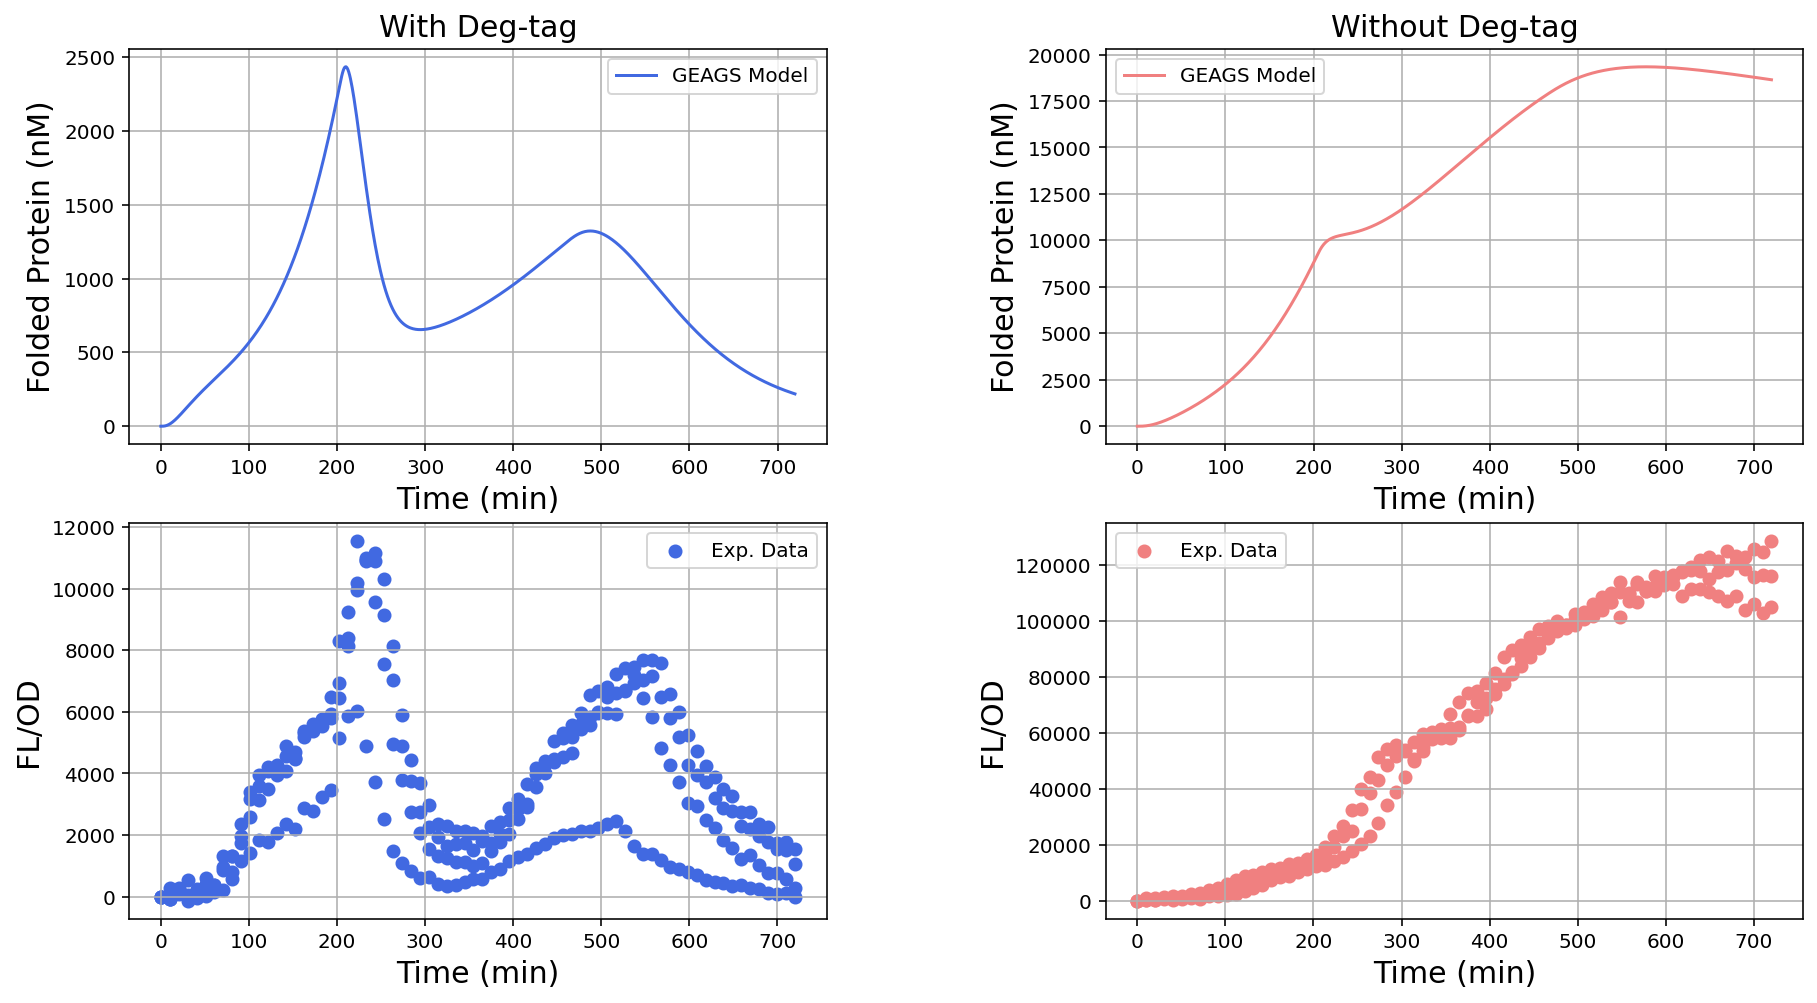

In [28]:
fig, ax = plt.subplots(2,2, figsize = (15,8))
fig.subplots_adjust(wspace = 0.4)#, hspace = 0.1)

r,c = 0,0
ax[r,c].plot(timepoints[:tf_I], sol_deg['protein_sfYFP'][:tf_I], label = "GEAGS Model", color = 'royalblue')
ax[r,c].set_xlabel('Time (min)', fontsize = 15) ; ax[r,c].set_ylabel('Folded Protein (nM)', fontsize = 15) 
ax[r,c].set_title('With Deg-tag', fontsize = 15) ; ax[r,c].grid(True) ; ax[r,c].legend()

r,c = 0,1
ax[r,c].plot(timepoints[:tf_I], sol_no_deg['protein_sfYFP'][:tf_I], label = "GEAGS Model", color = 'lightcoral')
ax[r,c].set_xlabel('Time (min)', fontsize = 15) ; ax[r,c].set_ylabel('Folded Protein (nM)', fontsize = 15) 
ax[r,c].set_title('Without Deg-tag', fontsize = 15) ; ax[r,c].grid(True) ; ax[r,c].legend()

r,c = 1,0
ax[r,c].scatter(time_A[0][:tf_i], A_non_leaky[0][:tf_i], color = 'royalblue', label = 'Exp. Data')
ax[r,c].scatter(time_A[1][:tf_i], A_non_leaky[1][:tf_i], color = 'royalblue')
ax[r,c].scatter(time_A[2][:tf_i], A_non_leaky[2][:tf_i], color = 'royalblue')
ax[r,c].scatter(time_A[3][:tf_i], A_non_leaky[3][:tf_i], color = 'royalblue')
ax[r,c].set_xlabel('Time (min)', fontsize = 15) ; ax[r,c].set_ylabel('FL/OD', fontsize = 15) ; ax[r,c].legend()
#ax[r,c].set_title('With Deg-tag') ; 
ax[r,c].grid(True)

r,c = 1,1
ax[r,c].scatter(time_B[0][:tf_i], B_non_leaky[0][:tf_i], color = 'lightcoral', label = 'Exp. Data')
ax[r,c].scatter(time_B[1][:tf_i], B_non_leaky[1][:tf_i], color = 'lightcoral')
ax[r,c].scatter(time_B[2][:tf_i], B_non_leaky[2][:tf_i], color = 'lightcoral')
ax[r,c].set_xlabel('Time (min)', fontsize = 15) ; ax[r,c].set_ylabel('FL/OD', fontsize = 15) ; ax[r,c].legend()
#ax[r,c].set_title('Without Deg-tag') ; 
ax[r,c].grid(True)

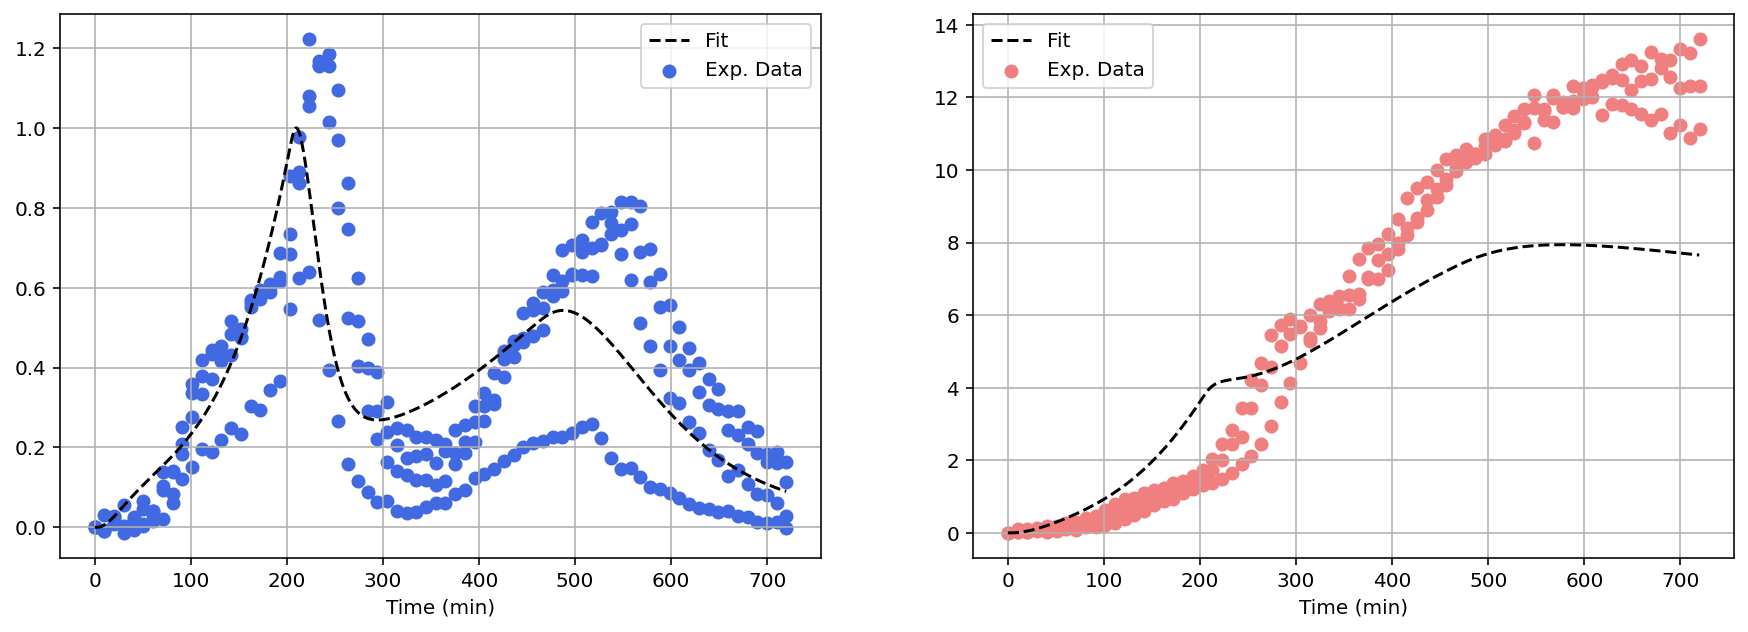

In [29]:
fig, ax = plt.subplots(1,2, figsize = (15,5))
#fig, ax = plt.subplots(2,1, figsize = (8,12))


ax[0].plot(timepoints[:tf_I], sol_deg['protein_sfYFP'][:tf_I]/np.max(sol_deg['protein_sfYFP']), '--', label = "Fit", color = 'black')
ax[0].scatter(time_A[0][:tf_i], A_non_leaky[0][:tf_i]/A_max, color = 'royalblue', label = 'Exp. Data')
ax[0].scatter(time_A[1][:tf_i], A_non_leaky[1][:tf_i]/A_max, color = 'royalblue')
ax[0].scatter(time_A[2][:tf_i], A_non_leaky[2][:tf_i]/A_max, color = 'royalblue')
ax[0].scatter(time_A[3][:tf_i], A_non_leaky[3][:tf_i]/A_max, color = 'royalblue')
ax[0].set_xlabel('Time (min)'); ax[0].grid(True) ; ax[0].legend()


ax[1].plot(timepoints[:tf_I], sol_no_deg['protein_sfYFP'][:tf_I]/np.max(sol_deg['protein_sfYFP']), '--', label = "Fit", color = 'black')
ax[1].scatter(time_B[0][:tf_i], B_non_leaky[0][:tf_i]/A_max, color = 'lightcoral', label = 'Exp. Data')
ax[1].scatter(time_B[1][:tf_i], B_non_leaky[1][:tf_i]/A_max, color = 'lightcoral')
ax[1].scatter(time_B[2][:tf_i], B_non_leaky[2][:tf_i]/A_max, color = 'lightcoral')
ax[1].set_xlabel('Time (min)'); ax[1].grid(True) ; ax[1].legend()

In [ ]:
def error_func(param, model_degtag, model_no_tag, *args, **kws):

    # Simulate the model with the given parameters for each replicate

    sol_deg_1, sol_no_deg_1 = run_CRN_model(param, model_degtag, model_no_tag, timepoints = time_A[0])
    sol_deg_2, sol_no_deg_2 = run_CRN_model(param, model_degtag, model_no_tag, timepoints = time_A[1])
    sol_deg_3, sol_no_deg_3 = run_CRN_model(param, model_degtag, model_no_tag, timepoints = time_A[2])
    sol_deg_4, sol_no_deg_4 = run_CRN_model(param, model_degtag, model_no_tag, timepoints = time_A[3])

    sol_deg_avg_max = np.mean([
    np.max(sol_deg_1['protein_sfYFP']),
    np.max(sol_deg_2['protein_sfYFP']),
    np.max(sol_deg_3['protein_sfYFP']),
    np.max(sol_deg_4['protein_sfYFP'])
])
    
    sol_no_deg_avg_max = np.mean([
    np.max(sol_no_deg_1['protein_sfYFP']),
    np.max(sol_no_deg_2['protein_sfYFP']),
    np.max(sol_no_deg_3['protein_sfYFP']),
    np.max(sol_no_deg_4['protein_sfYFP'])
])


    scaled_protein_1 = sol_deg_1['protein_sfYFP']/sol_deg_avg_max
    exp_A1 = A_non_leaky[0].reshape((len(A_non_leaky[0]),))
    e1 = (scaled_protein_1 - exp_A1/np.max(A_avg))**2 * 1
    

    scaled_protein_2 = sol_deg_2['protein_sfYFP']/sol_deg_avg_max
    exp_A2 = A_non_leaky[1].reshape((len(A_non_leaky[1]),))
    e2 = (scaled_protein_2 - exp_A2/np.max(A_avg))**2
    

    scaled_protein_3 = sol_deg_3['protein_sfYFP']/sol_deg_avg_max
    exp_A3 = A_non_leaky[2].reshape((len(A_non_leaky[2]),))
    e3 = (scaled_protein_3 - exp_A3/np.max(A_avg))**2

    scaled_protein_4 = sol_deg_4['protein_sfYFP']/sol_deg_avg_max
    exp_A4 = A_non_leaky[3].reshape((len(A_non_leaky[3]),))
    e7 = (scaled_protein_4 - exp_A4/np.max(A_avg))**2
    
    # calculate the fold change error individually for each replicate

    e4 = ((np.max(sol_no_deg_1['protein_sfYFP'])/np.max(sol_deg_1['protein_sfYFP'])) - avg_fold_change)**2
    e5 = ((np.max(sol_no_deg_2['protein_sfYFP'])/np.max(sol_deg_2['protein_sfYFP'])) - avg_fold_change)**2
    e6 = ((np.max(sol_no_deg_3['protein_sfYFP'])/np.max(sol_deg_3['protein_sfYFP'])) - avg_fold_change)**2
    e8 = ((np.max(sol_no_deg_4['protein_sfYFP'])/np.max(sol_deg_4['protein_sfYFP'])) - avg_fold_change)**2

    
    # define the weights for the error terms
    w1 = 1 
    w2 = 1

    e = (np.sum(e1) + np.sum(e2) + np.sum(e3) + np.sum(e7)) * w1 + (np.sum(e4) + np.sum(e5) + np.sum(e6)  + np.sum(e8)) * w2 
    
    return e

In [31]:
# Suppress ODEint warnings
warnings.filterwarnings('ignore')

def callback(params, iter, resid, *args, **kws):
    """Call back function to save the objective function values in each iteration"""
    itervalues = kws['itervalues']
    itervalues.append(resid)

itervalues = []

# # options = {'method' : 'nelder'} # if you want to use any different method in LMFIT
# results = lmfit.minimize(error_func, params, args = (model_degtag, model_no_tag), method = 'basinhopping')#, 
#                          #initial_temp  = 8000)#, minimizer_kwargs = options)
options_dict = {'adapt' : True}
results = lmfit.minimize(error_func, params, args = (model_degtag, model_no_tag), method = 'nelder',
                          options = {'adaptive' : True}, iter_cb = callback, kws = {'itervalues':itervalues})
results

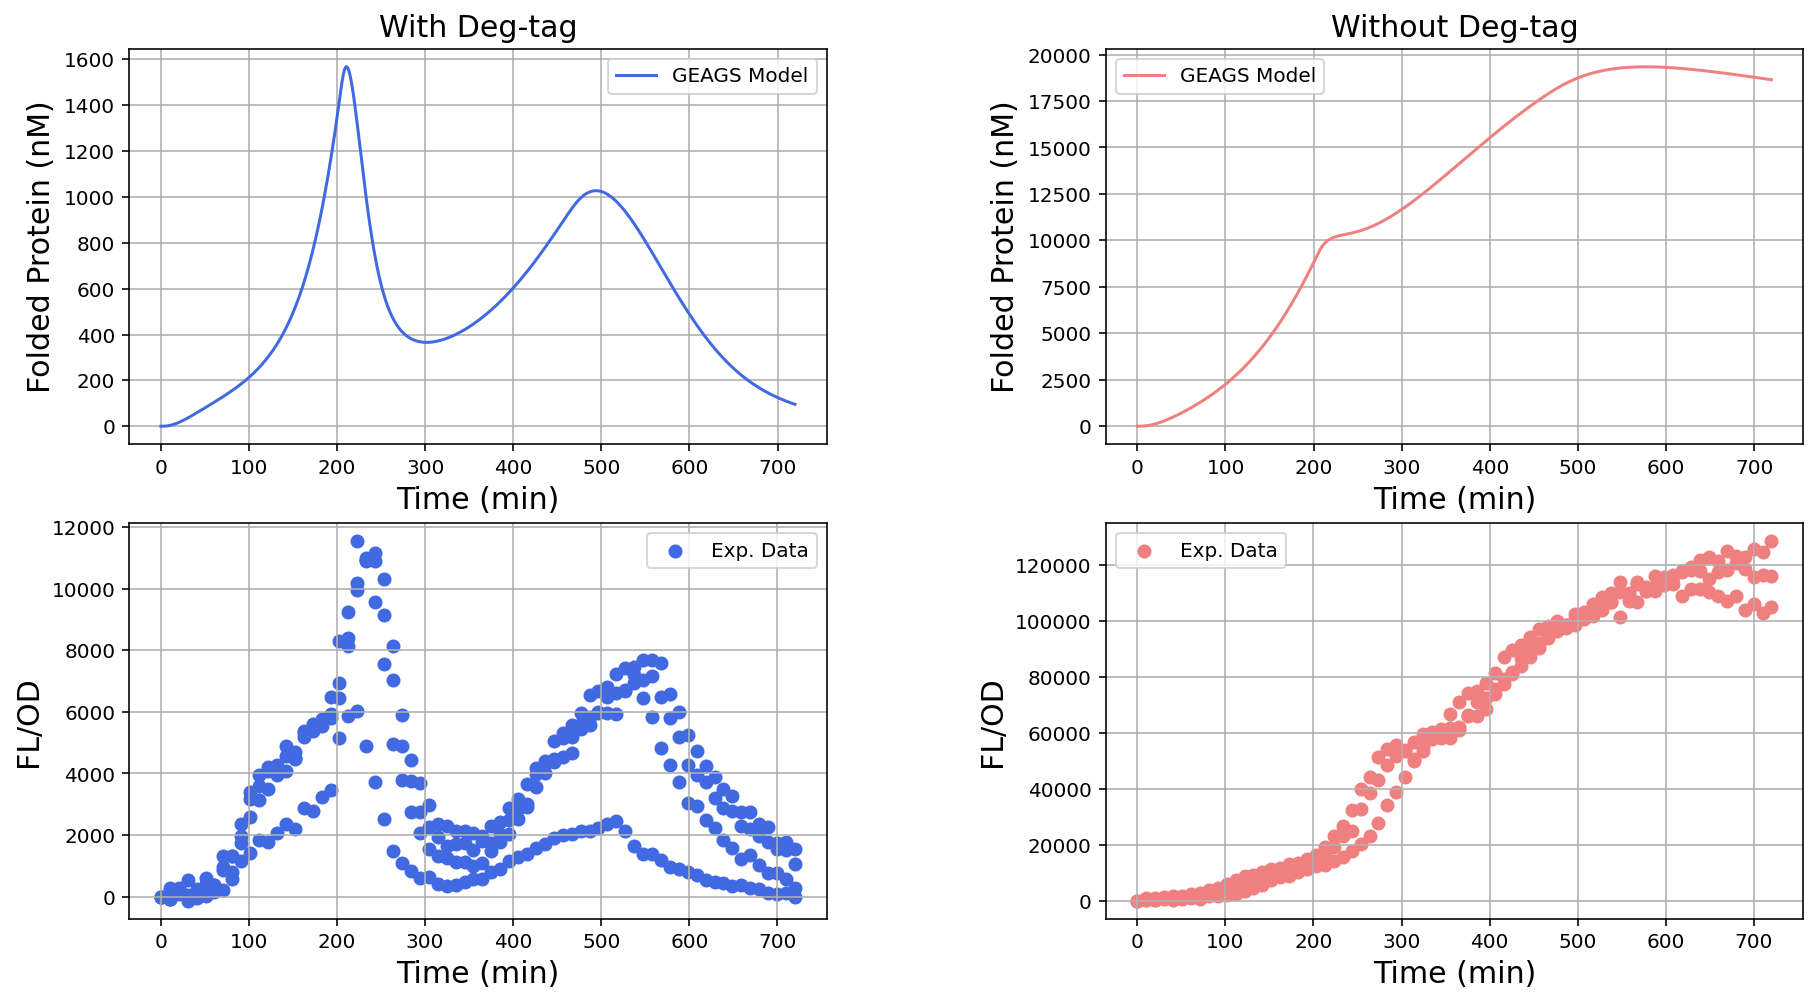

In [32]:
param_fit = results.params

sol_deg, sol_no_deg = run_CRN_model(param_fit, model_degtag, model_no_tag, timepoints)

fig, ax = plt.subplots(2,2, figsize = (15,8))
fig.subplots_adjust(wspace = 0.4)#, hspace = 0.1)

r,c = 0,0
ax[r,c].plot(timepoints[:tf_I], sol_deg['protein_sfYFP'][:tf_I], label = "GEAGS Model", color = 'royalblue')
ax[r,c].set_xlabel('Time (min)', fontsize = 15) ; ax[r,c].set_ylabel('Folded Protein (nM)', fontsize = 15) 
ax[r,c].set_title('With Deg-tag', fontsize = 15) ; ax[r,c].grid(True) ; ax[r,c].legend()

r,c = 0,1
ax[r,c].plot(timepoints[:tf_I], sol_no_deg['protein_sfYFP'][:tf_I], label = "GEAGS Model", color = 'lightcoral')
ax[r,c].set_xlabel('Time (min)', fontsize = 15) ; ax[r,c].set_ylabel('Folded Protein (nM)', fontsize = 15) 
ax[r,c].set_title('Without Deg-tag', fontsize = 15) ; ax[r,c].grid(True) ; ax[r,c].legend()

r,c = 1,0
ax[r,c].scatter(time_A[0][:tf_i], A_non_leaky[0][:tf_i], color = 'royalblue', label = 'Exp. Data')
ax[r,c].scatter(time_A[1][:tf_i], A_non_leaky[1][:tf_i], color = 'royalblue')
ax[r,c].scatter(time_A[2][:tf_i], A_non_leaky[2][:tf_i], color = 'royalblue')
ax[r,c].scatter(time_A[3][:tf_i], A_non_leaky[3][:tf_i], color = 'royalblue')
ax[r,c].set_xlabel('Time (min)', fontsize = 15) ; ax[r,c].set_ylabel('FL/OD', fontsize = 15) ; ax[r,c].legend()
#ax[r,c].set_title('With Deg-tag') ; 
ax[r,c].grid(True)

r,c = 1,1
ax[r,c].scatter(time_B[0][:tf_i], B_non_leaky[0][:tf_i], color = 'lightcoral', label = 'Exp. Data')
ax[r,c].scatter(time_B[1][:tf_i], B_non_leaky[1][:tf_i], color = 'lightcoral')
ax[r,c].scatter(time_B[2][:tf_i], B_non_leaky[2][:tf_i], color = 'lightcoral')
ax[r,c].set_xlabel('Time (min)', fontsize = 15) ; ax[r,c].set_ylabel('FL/OD', fontsize = 15) ; ax[r,c].legend()
#ax[r,c].set_title('Without Deg-tag') ; 
ax[r,c].grid(True)

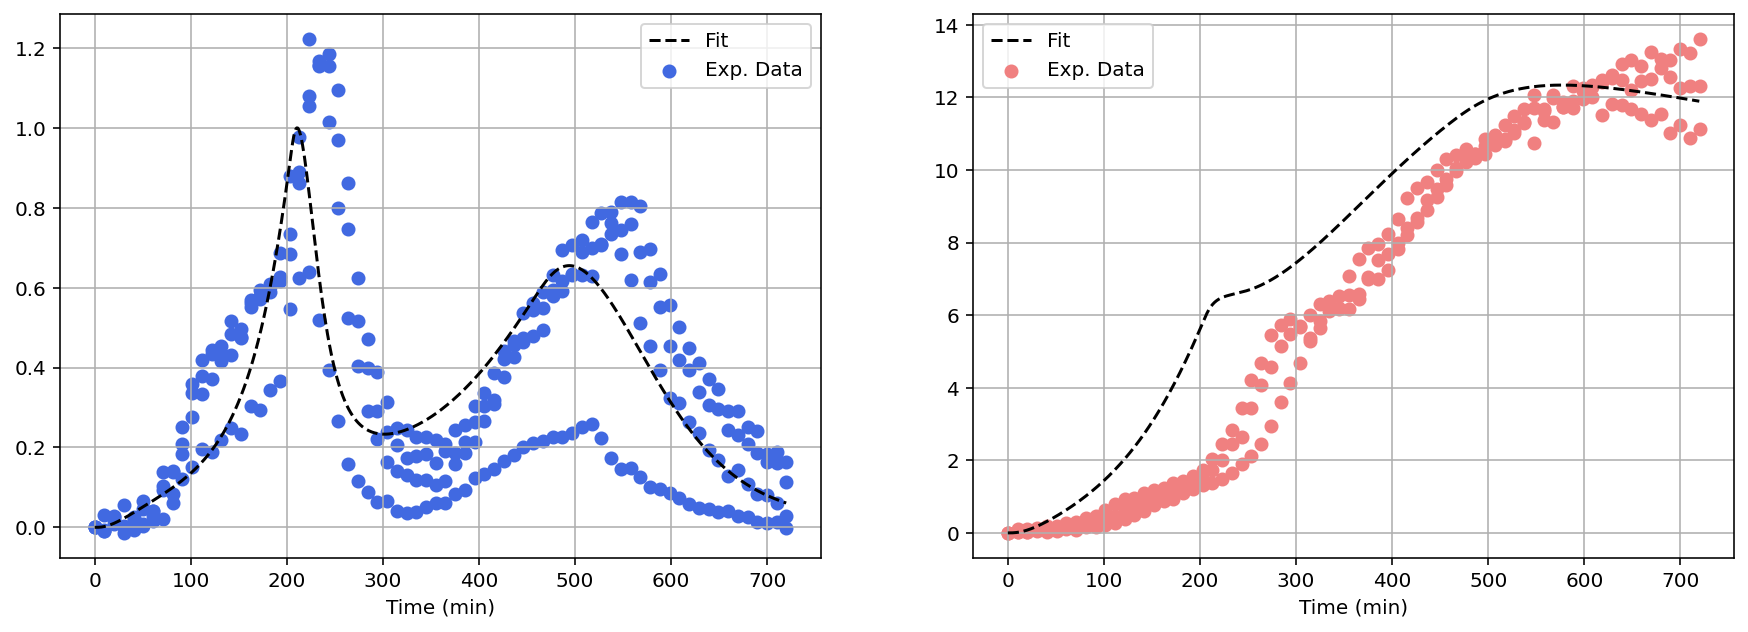

In [33]:
fig, ax = plt.subplots(1,2, figsize = (15,5))
#fig, ax = plt.subplots(2,1, figsize = (8,12))


ax[0].plot(timepoints[:tf_I], sol_deg['protein_sfYFP'][:tf_I]/np.max(sol_deg['protein_sfYFP']), '--', label = "Fit", color = 'black')
ax[0].scatter(time_A[0][:tf_i], A_non_leaky[0][:tf_i]/A_max, color = 'royalblue', label = 'Exp. Data')
ax[0].scatter(time_A[1][:tf_i], A_non_leaky[1][:tf_i]/A_max, color = 'royalblue')
ax[0].scatter(time_A[2][:tf_i], A_non_leaky[2][:tf_i]/A_max, color = 'royalblue')
ax[0].scatter(time_A[3][:tf_i], A_non_leaky[3][:tf_i]/A_max, color = 'royalblue')
ax[0].set_xlabel('Time (min)'); ax[0].grid(True) ; ax[0].legend()


ax[1].plot(timepoints[:tf_I], sol_no_deg['protein_sfYFP'][:tf_I]/np.max(sol_deg['protein_sfYFP']), '--', label = "Fit", color = 'black')
ax[1].scatter(time_B[0][:tf_i], B_non_leaky[0][:tf_i]/A_max, color = 'lightcoral', label = 'Exp. Data')
ax[1].scatter(time_B[1][:tf_i], B_non_leaky[1][:tf_i]/A_max, color = 'lightcoral')
ax[1].scatter(time_B[2][:tf_i], B_non_leaky[2][:tf_i]/A_max, color = 'lightcoral')
ax[1].set_xlabel('Time (min)'); ax[1].grid(True) ; ax[1].legend()

Text(0.5, 1.0, 'Loss Function over \n number of Iterations')

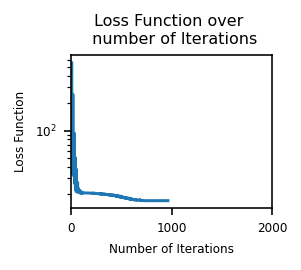

In [34]:
# Plotting the loss function as a function of number of iterations in optimzation

n_iters = range(len(itervalues))
plt.figure(figsize = (1.8, 1.4))
plt.plot(n_iters, itervalues)
plt.yscale('log')
plt.xlim((0, 2000))
#plt.ylim((0,500))
plt.xlabel('Number of Iterations', fontsize = 6)
plt.ylabel('Loss Function', fontsize = 6)
plt.xticks(fontsize = 6) ; plt.yticks(fontsize = 6)
plt.title('Loss Function over \n number of Iterations', fontsize = 8)
#plt.savefig('Loss_function_niter.svg', dpi = 300)

In [36]:
# Export parameters. Save if good otherwise modify the parameter file and run again

param_dict = param_fit.valuesdict()
# param_dict_guess_df = dict()
# param_dict_guess_df['Param name'] = param_dict.keys()
# param_dict_guess_df['Param'] = param_dict.values()
# param_data = pd.DataFrame(data = param_dict_guess_df)
# param_data.to_csv('params_best_fit_091725_only_deg_params.csv')
param_dict

{'n_gamma_RNAP': 0.23,
 'n_gamma_Et': 0.37,
 'n_gamma_tRNA': 0.6,
 'n_gamma_Ribo': 0.67,
 'n_gamma_Protease': 0.45237598797867523,
 'Sigma_IC': 135.0,
 'NT_IC': 942.0,
 'RNAase_IC': 90.0,
 'AA_IC': 85610.0,
 'Ribo_max': 280.0,
 'tRNA_max': 1535.0,
 'RNAP_max': 1960.0,
 'Et_max': 1090.0,
 'Protease_max': 6146.866936691339,
 'k_tx_1b': 0.05061,
 'k_tx_1u': 14.081,
 'k_tx_2b': 0.0019382,
 'k_tx_2u': 0.09999,
 'k_tx_3': 0.003597,
 'k_tx_4b': 2.54926,
 'k_tx_4u': 161.36218,
 'k_tx_5': 0.42521,
 'k_tl_1b': 0.002793,
 'k_tl_1u': 11.48224,
 'k_tl_2u': 35.1135,
 'k_tl_2b': 8.24109,
 'k_tl_3b': 0.04287,
 'k_tl_3u': 12.3438,
 'k_tl_4': 0.17,
 'k_tl_5': 0.10047,
 'b_tl_5': 0.5007,
 'k_tl_6': 0.0483677729298024,
 'k_tl_7': 0.0008,
 'k_tl_8': 138.0,
 'k_tl_9b_P': 0.000454,
 'k_tl_9b_Pm': 0.2033128764912187,
 'k_tl_9u': 44.19785628188373,
 'k_tl_10': 0.0001,
 'n_gamma_folding': 0.26,
 'n_gamma_syn': 0.296,
 'C_max': 501250000.0,
 'C_0': 6666666.67,
 'k_gr': 0.015883705}